In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
df = pd.read_csv('../../data/cleaned/renewal_calls_cleaned.csv', low_memory=False)
df.shape

(153269, 52)

In [60]:
df.head()

,call_id,call_direction,co_ref,call_date,complaint_category,customer_reaction_category,agent_renewal_pitch_category,customer_renewal_response_category,agent_response_category,membership_renewal_decision,...,agent_initiated_renewal_flag,competitor_mentioned_flag,switching_intent_flag,price_switching_flag,pct_price_increase_flag,monetary_price_increase_flag,customer_asked_justification_flag,discount_offered_flag,renewal_confirmed_flag,customer_response_score
0,5.950000e+11,Outbound,UB0899,2025-01-29,NaN,Not Mentioned,Discussion / Introduction / Inquiry,Discount and Offer,Discount and Offer,No,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,5.970000e+11,Outbound,HN5141,2025-02-26,NaN,NaN,Price and Cost,Agreement,Customer Communication,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,5.950000e+11,Outbound,BP5009,2025-01-24,NaN,NaN,Expiration / Due,Agreement,Accreditation and Certification,No,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,6.520000e+11,Outbound,XP8119,2025-06-09,NaN,NaN,Auto / Automatic,Agreement,Accreditation and Certification,No,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,5.370000e+11,Outbound,ZL7978,2024-08-20,NaN,NaN,NaN,NaN,NaN,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


## Univariate Analysis
Call direction distribution

In [61]:
direction_counts = df['call_direction'].value_counts()
direction_counts

call_direction
Outbound    131468
Inbound      21801
Name: count, dtype: int64

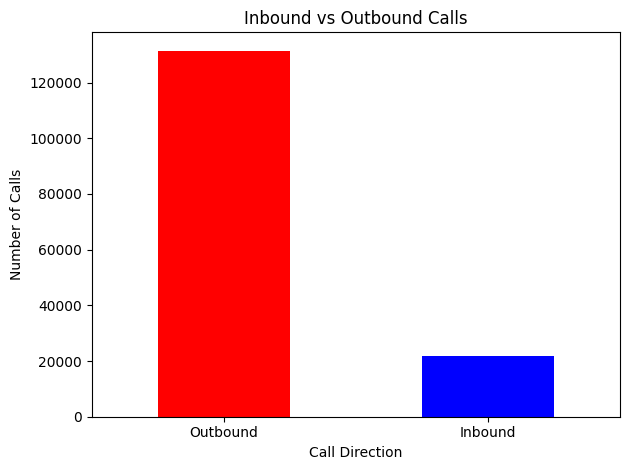

In [62]:
direction_counts.plot(kind='bar', color=['red', 'blue'])
plt.title('Inbound vs Outbound Calls')
plt.xlabel('Call Direction')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../../reports/figures/rc_01_call_direction.png')
plt.show()

Membership renewal decision

In [63]:
renewal_counts = df['membership_renewal_decision'].value_counts()
renewal_counts

membership_renewal_decision
No        73884
Yes        8738
Yes/No       13
Name: count, dtype: int64

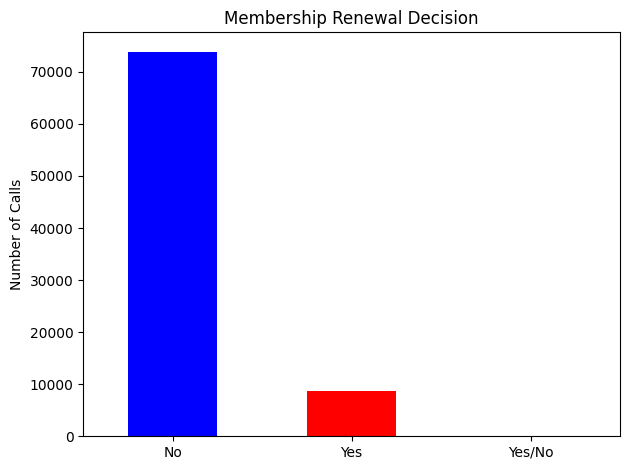

In [64]:
renewal_counts.plot(kind='bar', color=['blue', 'red'])
plt.title('Membership Renewal Decision')
plt.xlabel('')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../../reports/figures/rc_02_renewal_decision.png')
plt.show()

Did the customer make a serious complaint?

In [65]:
complaint_counts = df['serious_complaint'].value_counts()
complaint_counts

serious_complaint
No        79842
Yes         589
Yes/No        1
Name: count, dtype: int64

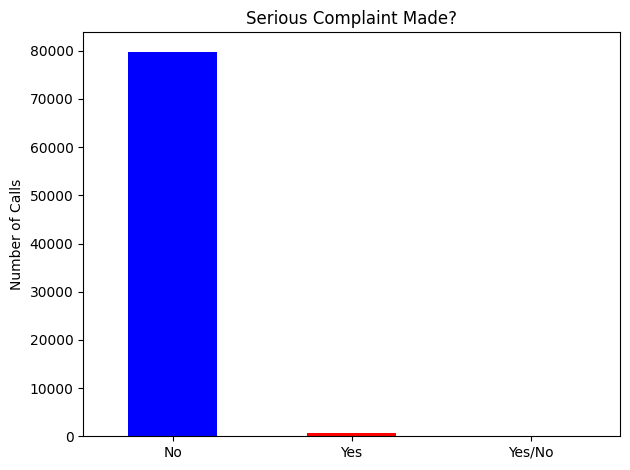

In [66]:
complaint_counts.plot(kind='bar', color=['blue', 'red'])
plt.title('Serious Complaint Made?')
plt.xlabel('')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../../reports/figures/rc_03_serious_complaint.png')
plt.show()

Was price increase discussed?

In [67]:
price_counts = df['discussion_on_price_increase'].value_counts()
price_counts

discussion_on_price_increase
No          75911
Yes          8079
[Yes/No]       26
**No**          1
Name: count, dtype: int64

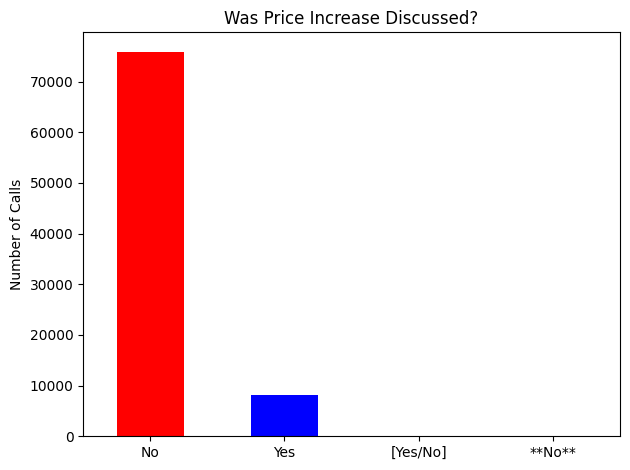

In [68]:
price_counts.plot(kind='bar', color=['red', 'blue'])
plt.title('Was Price Increase Discussed?')
plt.xlabel('')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../../reports/figures/rc_04_price_discussed.png')
plt.show()

Was a competitor mentioned?

In [69]:
competitor_counts = df['explicit_competitor_mention'].value_counts()
competitor_counts

explicit_competitor_mention
No             83214
Yes             1393
XXXX              25
UNAVAILABLE        2
Prompt 2:          1
[No]               1
Name: count, dtype: int64

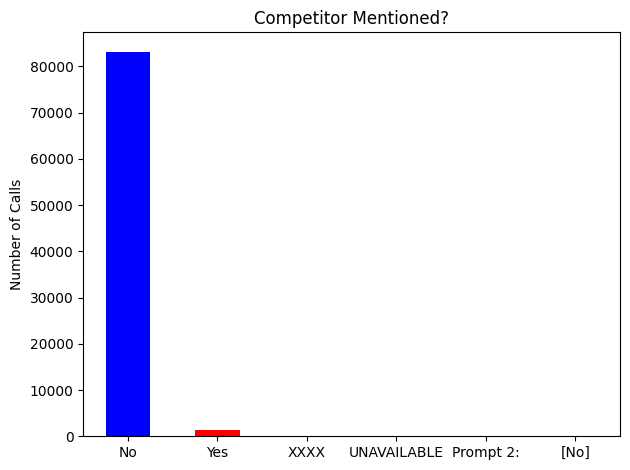

In [70]:
competitor_counts.plot(kind='bar', color=['blue', 'red'])
plt.title('Competitor Mentioned?')
plt.xlabel('')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../../reports/figures/rc_05_competitor_mentioned.png')
plt.show()

In [71]:
print('Univariate Summary:')
print(f'- Most calls were {df["call_direction"].value_counts().idxmax()} — {df["call_direction"].value_counts().max()} calls')
print(f'- Renewal decision: {df["membership_renewal_decision"].value_counts().to_dict()}')
print(f'- Serious complaints: {df["serious_complaint"].value_counts().get("Yes", 0)} calls')
print(f'- Price discussed: {df["discussion_on_price_increase"].value_counts().get("Yes", 0)} calls')
print(f'- Competitor mentioned: {df["explicit_competitor_mention"].value_counts().get("Yes", 0)} calls')

Univariate Summary:
- Most calls were Outbound — 131468 calls
- Renewal decision: {'No': 73884, 'Yes': 8738, 'Yes/No': 13}
- Serious complaints: 589 calls
- Price discussed: 8079 calls
- Competitor mentioned: 1393 calls


## Bivariate Analysis
Comparing two columns together to find relationships.

Does a serious complaint affect renewal decision?

In [72]:
complained_yes = df[df['serious_complaint'] == 'Yes']
complained_no  = df[df['serious_complaint'] == 'No']

renewed_yes = (complained_yes['membership_renewal_decision'] == 'Yes').sum()
renewed_no  = (complained_no['membership_renewal_decision'] == 'Yes').sum()

print(f'Renewed when serious complaint: {renewed_yes} out of {len(complained_yes)}')
print(f'Renewed when no serious complaint: {renewed_no} out of {len(complained_no)}')

Renewed when serious complaint: 315 out of 589
Renewed when no serious complaint: 7932 out of 79842


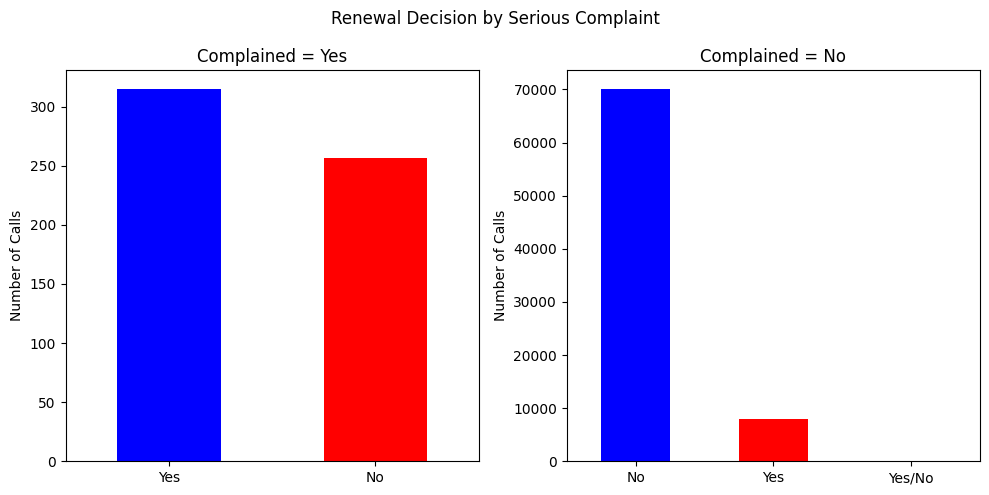

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

complained_yes['membership_renewal_decision'].value_counts().plot(kind='bar', ax=axes[0], color=['blue', 'red'])
axes[0].set_title('Complained = Yes')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Calls')
axes[0].tick_params(axis='x', rotation=0)

complained_no['membership_renewal_decision'].value_counts().plot(kind='bar', ax=axes[1], color=['blue', 'red'])
axes[1].set_title('Complained = No')
axes[1].set_xlabel('')
axes[1].set_ylabel('Number of Calls')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Renewal Decision by Serious Complaint')
plt.tight_layout()
plt.savefig('../../reports/figures/rc_07_complaint_vs_renewal.png')
plt.show()

Does price discussion affect renewal decision?

In [74]:
price_yes = df[df['discussion_on_price_increase'] == 'Yes']
price_no  = df[df['discussion_on_price_increase'] == 'No']

cross = pd.crosstab(df['discussion_on_price_increase'], df['membership_renewal_decision'])
print(cross)

membership_renewal_decision      No   Yes  Yes/No
discussion_on_price_increase                     
**No**                            1     0       0
No                            67158  7227       6
Yes                            6172  1434       0
[Yes/No]                         20     0       6


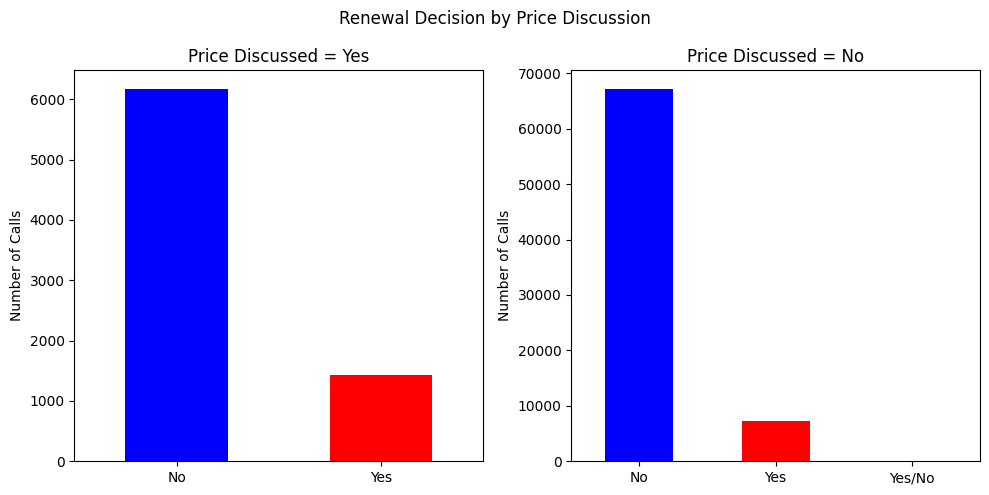

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

price_yes['membership_renewal_decision'].value_counts().plot(kind='bar', ax=axes[0], color=['blue', 'red'])
axes[0].set_title('Price Discussed = Yes')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Calls')
axes[0].tick_params(axis='x', rotation=0)

price_no['membership_renewal_decision'].value_counts().plot(kind='bar', ax=axes[1], color=['blue', 'red'])
axes[1].set_title('Price Discussed = No')
axes[1].set_xlabel('')
axes[1].set_ylabel('Number of Calls')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Renewal Decision by Price Discussion')
plt.tight_layout()
plt.savefig('../../reports/figures/rc_08_price_vs_renewal.png')
plt.show()

Does call direction affect renewal decision?

In [76]:
cross = pd.crosstab(df['call_direction'], df['membership_renewal_decision'])
print(cross)

membership_renewal_decision     No   Yes  Yes/No
call_direction                                  
Inbound                      15070  1509       0
Outbound                     58814  7229      13


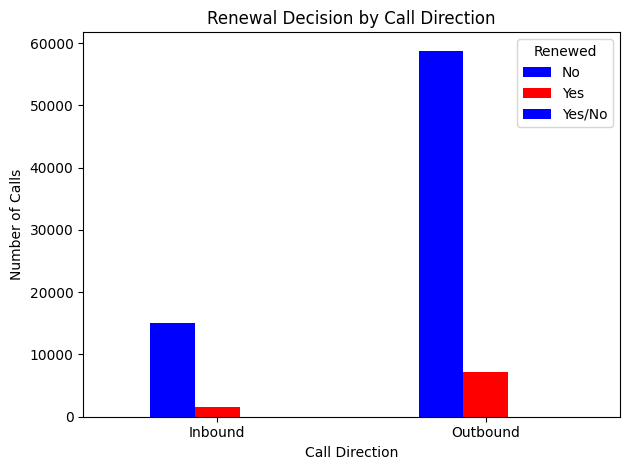

In [77]:
cross.plot(kind='bar', color=['blue', 'red'])
plt.title('Renewal Decision by Call Direction')
plt.xlabel('Call Direction')
plt.ylabel('Number of Calls')
plt.xticks(rotation=0)
plt.legend(title='Renewed')
plt.tight_layout()
plt.savefig('../../reports/figures/rc_09_direction_vs_renewal.png')
plt.show()

In [78]:
print('Bivariate Summary:')
print('- Serious complaints may affect whether customers renew')
print('- Price discussion may influence renewal decision')
print('- Call direction shows different renewal patterns')

Bivariate Summary:
- Serious complaints may affect whether customers renew
- Price discussion may influence renewal decision
- Call direction shows different renewal patterns


## Multivariate Analysis
Looking at three or more columns together to find deeper patterns.

Complaint + Price Discussion + Renewal Decision together

In [79]:
pivot = df.groupby(['serious_complaint', 'discussion_on_price_increase'])['membership_renewal_decision'].value_counts().unstack(fill_value=0)
print(pivot)

membership_renewal_decision                        No   Yes  Yes/No
serious_complaint discussion_on_price_increase                     
No                **No**                            1     0       0
                  No                            63768  6576       6
                  Yes                            5808  1292       0
                  [Yes/No]                         20     0       5
Yes               No                              187   257       0
                  Yes                              66    54       0
Yes/No            [Yes/No]                          0     0       1


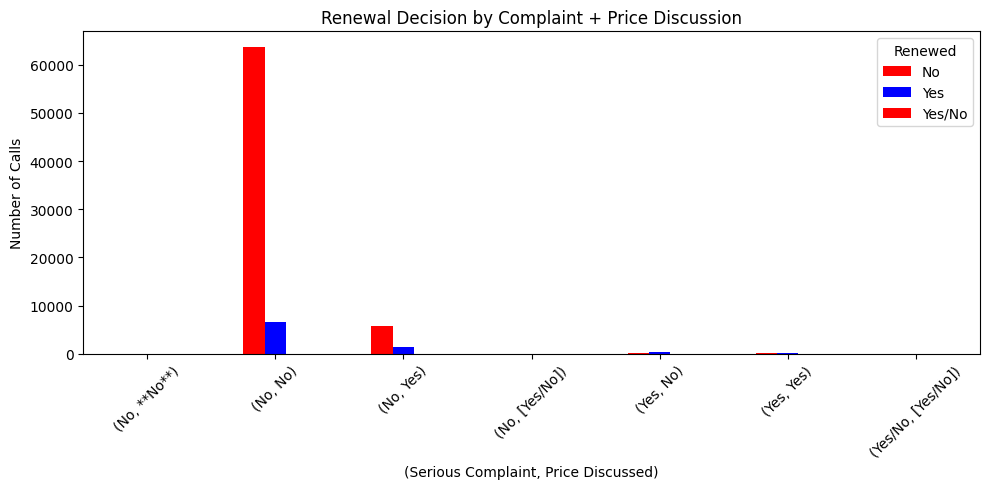

In [80]:
pivot.plot(kind='bar', figsize=(10, 5), color=['red', 'blue'])
plt.title('Renewal Decision by Complaint + Price Discussion')
plt.xlabel('(Serious Complaint, Price Discussed)')
plt.ylabel('Number of Calls')
plt.xticks(rotation=45)
plt.legend(title='Renewed')
plt.tight_layout()
plt.savefig('../../reports/figures/rc_10_complaint_price_renewal.png')
plt.show()

In [81]:
print('Multivariate Summary:')
print('- Complaints combined with price discussion show strongest non-renewal pattern')

Multivariate Summary:
- Complaints combined with price discussion show strongest non-renewal pattern


## Correlation Analysis
How strongly are the different flag features related to each other?

In [82]:
flag_cols = [c for c in df.columns if c.endswith('_flag')]
corr_matrix = df[flag_cols].corr()
corr_matrix

,serious_complaint_flag,other_complaint_flag,price_discussed_flag,price_impact_renewal_flag,discount_requested_flag,call_reschedule_flag,membership_alert_flag,agent_initiated_renewal_flag,competitor_mentioned_flag,switching_intent_flag,price_switching_flag,pct_price_increase_flag,monetary_price_increase_flag,customer_asked_justification_flag,discount_offered_flag,renewal_confirmed_flag
serious_complaint_flag,1.000000,0.087803,0.035611,0.099149,0.017166,-0.003241,-0.003829,0.011065,-0.003124,0.002924,0.026972,0.005817,0.027000,0.099317,0.006195,0.124743
other_complaint_flag,0.087803,1.000000,0.297586,0.250212,0.208711,-0.039525,0.115552,-0.013990,0.042158,0.020869,0.227017,0.114807,0.136207,0.375302,0.185490,0.163217
price_discussed_flag,0.035611,0.297586,1.000000,0.327472,0.377058,-0.022898,0.016274,0.133441,0.041468,0.008562,0.369388,0.240785,0.384460,0.582373,0.391003,0.086082
price_impact_renewal_flag,0.099149,0.250212,0.327472,1.000000,0.262995,-0.003961,0.029054,0.105811,0.051484,0.045976,0.409340,0.066349,0.114564,0.335873,0.316693,0.431307
discount_requested_flag,0.017166,0.208711,0.377058,0.262995,1.000000,-0.014390,0.029201,0.069088,0.048185,0.002308,0.285873,0.132919,0.158494,0.426517,0.379859,0.063403
call_reschedule_flag,-0.003241,-0.039525,-0.022898,-0.003961,-0.014390,1.000000,-0.011687,-0.000971,-0.011918,0.000178,-0.009744,-0.013241,-0.021701,-0.023644,-0.005893,-0.021318
membership_alert_flag,-0.003829,0.115552,0.016274,0.029054,0.029201,-0.011687,1.000000,0.083291,-0.010971,0.003981,0.009252,-0.008602,-0.013667,0.023956,0.066809,-0.000921
agent_initiated_renewal_flag,0.011065,-0.013990,0.133441,0.105811,0.069088,-0.000971,0.083291,1.000000,-0.023554,0.004876,0.074157,0.010866,0.083827,0.092266,0.191688,0.079083
competitor_mentioned_flag,-0.003124,0.042158,0.041468,0.051484,0.048185,-0.011918,-0.010971,-0.023554,1.000000,0.185628,0.123316,0.007602,0.031451,0.055488,0.046789,0.055222
switching_intent_flag,0.002924,0.020869,0.008562,0.045976,0.002308,0.000178,0.003981,0.004876,0.185628,1.000000,0.052442,0.002464,0.004301,0.013402,0.020930,0.068137


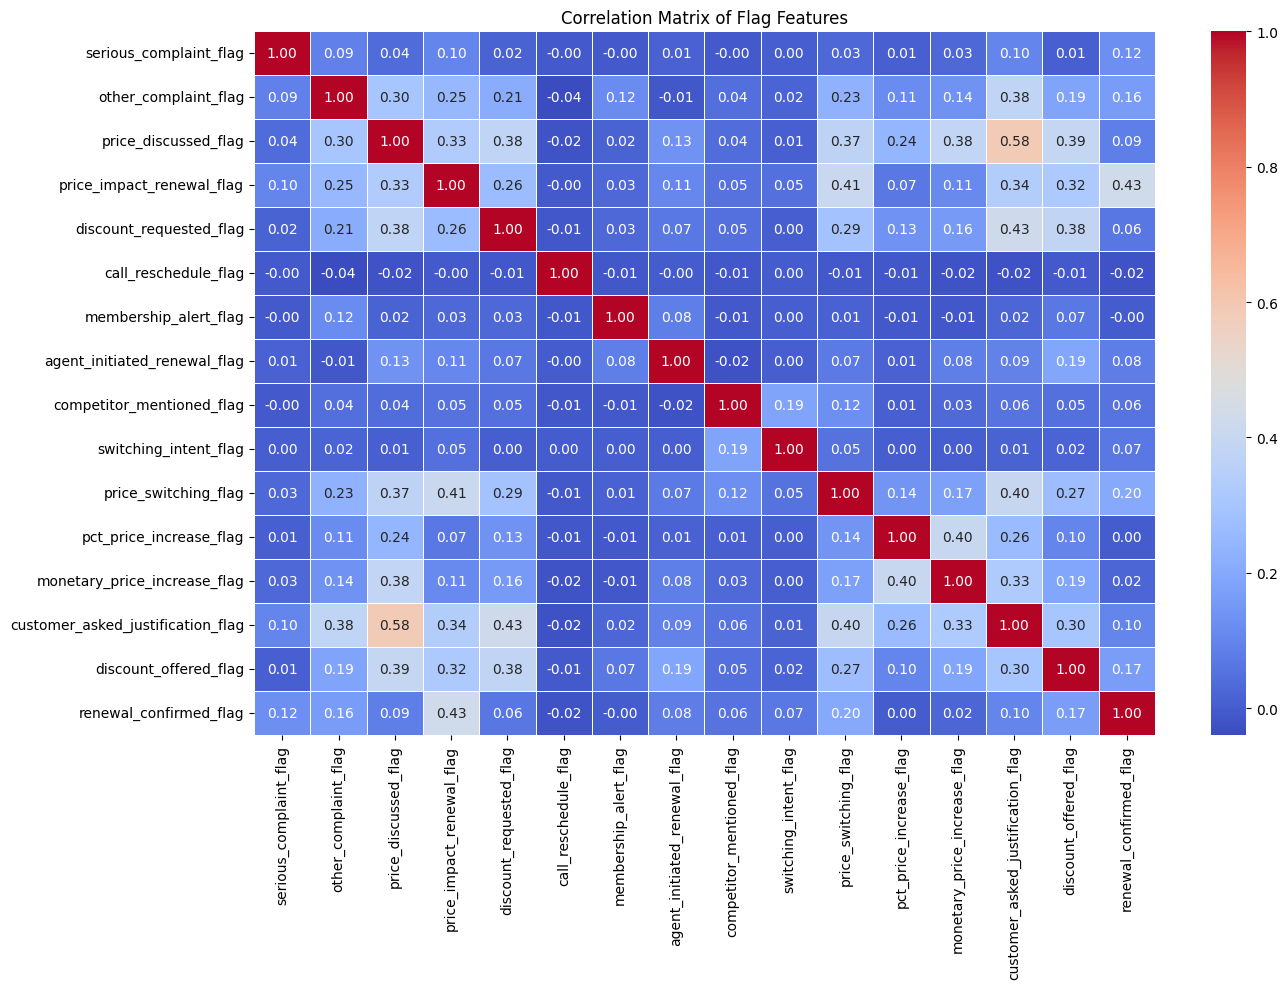

In [83]:
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Flag Features')
plt.tight_layout()
plt.savefig('../../reports/figures/rc_12_correlation_heatmap.png')
plt.show()